In [ ]:
import astropy.units as u
import astropy.constants as const
import os

# 1. Zkontrolujeme, jestli proměnné přišly z vnějšího wrapperu
if 'M_BH' not in locals():
    M_BH = 1e4
if 'm_s_val' not in locals():
    m_s_val = 1e-21

print(f"--- DBSCAN analyzuje: M_BH={M_BH:.1e}, m_s={m_s_val:.1e} ---")

# 2. Vytvoříme astropy objekty na základě dynamického m_s_val
m_s_eV = m_s_val * u.eV
mass_s = (m_s_eV / const.c**2).to(u.Msun)

# 3. Přepočet konstant
c = const.c.to(u.kpc / u.Gyr)
G = const.G.to(u.kpc**3 / (u.Msun * u.Gyr**2))
h_bar = const.hbar.to(u.Msun * u.kpc**2 / u.Gyr)

# 4. Výpočet h_bar_tilde
h_bar_tilde = (h_bar / mass_s).to(u.kpc**2 / u.Gyr)

# 5. Uložení čistých číselných hodnot pro solver
G_val = G.value
h_bar_tilde_val = h_bar_tilde.value
HBAR_TILDE = h_bar_tilde_val 

print(f"-> Spočteno: HBAR_TILDE = {HBAR_TILDE:.4e}")

In [11]:
import subprocess, sys, os
from scipy.integrate import odeint
import matplotlib.pyplot as plt

#cmd = [sys.executable, "ModosFinder.py"]
#p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

import time
#time.sleep(1)
#print("poll =", p.poll())   # None = pořád běží, číslo = exit code

#import os, sys
#print("marimo cwd:", os.getcwd())
#print("python:", sys.executable)
#print("ModoFinder exists here?:", os.path.exists("ModosFinder.py"))


# vytiskni pár řádků výstupu:
#for _ in range(20):
#    line = p.stdout.readline()
#    if not line:
#        break
#    print(line, end="")


poll = None
marimo cwd: /home/smidmar9/Projects/Reasearch-task/Research-task
python: /home/smidmar9/.venv/bin/python3
ModoFinder exists here?: True
running with 7.842780153469577
Hurrah! U0=-1.000e+00, omega=3.541e-01, rn=2.042e+00
Hurrah! U0=-1.000e+00, omega=4.349e-01, rn=3.105e+00
Hurrah! U0=-1.000e+00, omega=1.427e-01, rn=2.103e+00
Hurrah! U0=-1.000e+00, omega=4.723e-01, rn=3.099e+00
Hurrah! U0=-1.000e+00, omega=1.024e-01, rn=3.247e+00
Hurrah! U0=-1.000e+00, omega=9.109e-02, rn=3.272e+00
Hurrah! U0=-1.000e+00, omega=3.492e-01, rn=1.130e+00
Hurrah! U0=-1.000e+00, omega=9.763e-02, rn=2.117e+00
Hurrah! U0=-1.000e+00, omega=3.894e-01, rn=4.370e-01
Hurrah! U0=-1.000e+00, omega=3.594e-01, rn=2.068e+00
Hurrah! U0=-1.000e+00, omega=3.994e-01, rn=2.030e+00
Hurrah! U0=-1.000e+00, omega=1.422e-01, rn=3.204e+00
Hurrah! U0=-1.000e+00, omega=4.407e-02, rn=3.232e+00
Hurrah! U0=-1.000e+00, omega=2.046e-01, rn=2.104e+00
Hurrah! U0=-1.000e+00, omega=3.633e-01, rn=3.199e+00
Hurrah! U0=-1.000e+00, ome

In [239]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from scipy.integrate import odeint
from scipy.optimize import newton
from multiprocessing import Process 
import os
import warnings

warnings.filterwarnings('error')
Ncores = os.cpu_count()
AS = 0.0

G_KPC3_MSUN_GYR2 = 4.4986381856937695e-6
HBAR_TILDE =h_bar_tilde_val #m_s tkaed 2.5e-22eV
Ncores = os.cpu_count()
AS = 0.0
EPS_KPC = 1e-10

def gpp(y, r, omega, a_s=AS):
    Phi, U, A, B = y
    rr = r if r > EPS_KPC else EPS_KPC
    Ubh = -G_KPC3_MSUN_GYR2 * M_BH / (HBAR_TILDE**2 * rr)
    Utot = U + Ubh

    if r == 0:
        dydr = [A, B, 2*(Utot + a_s*Phi**2 - omega)*Phi/3.0, 4*np.pi*Phi**2/3.0]
    else:
        dydr = [A, B, 2*(Utot + a_s*Phi**2 - omega)*Phi - (2.0/r)*A, 4*np.pi*Phi**2 - (2.0/r)*B]
    return dydr
    
def Sol(r,U0,omega):
    y0 = [1.0, U0, 0.0, 0.0] ##condiciones iniciales, como podrá ver U0 y Uprime son las condiciones iniciales de U
    sol = odeint(gpp, y0, r, args=(omega,))
    return sol



def Phiinft(r,U0=-1.3473803,omega=-0.69831):
     return Sol(r,U0,omega)[:,0][m-1]
def recta(x,a,m):
    return x*m+a
def TotalMass(Malla,r):
    return 4*np.pi*np.sum((r[1]-r[0])*r**2*np.abs(Malla)**2)
suffix = f"{M_BH:.0e}_{HBAR_TILDE:.1e}".replace("+0", "").replace("+", "")

input_file = f"Sols_{M_BH:.1e}_{m_s_val:.1e}.txt"
Modos = np.loadtxt(input_file)
# Modos = Modos[(Modos[:,0]>-10),:]
# Modos = Modos[(Modos[:,0]>-2.6)&(Modos[:,0]<-2.5),:]
# Modos = Modos[(Modos[:,1]<-1.5),:]
# Modos[:,1] = Modos[:,1]-Modos[:,0]
# Modos[:,1] = Modos[:,1]/100


In [240]:
#Modos[:,0] = -5.3 #-0.1#-1.3


Estimated number of clusters: 1
Estimated number of noise points: 0


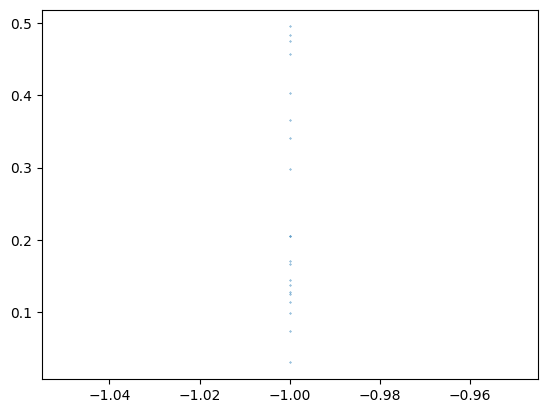

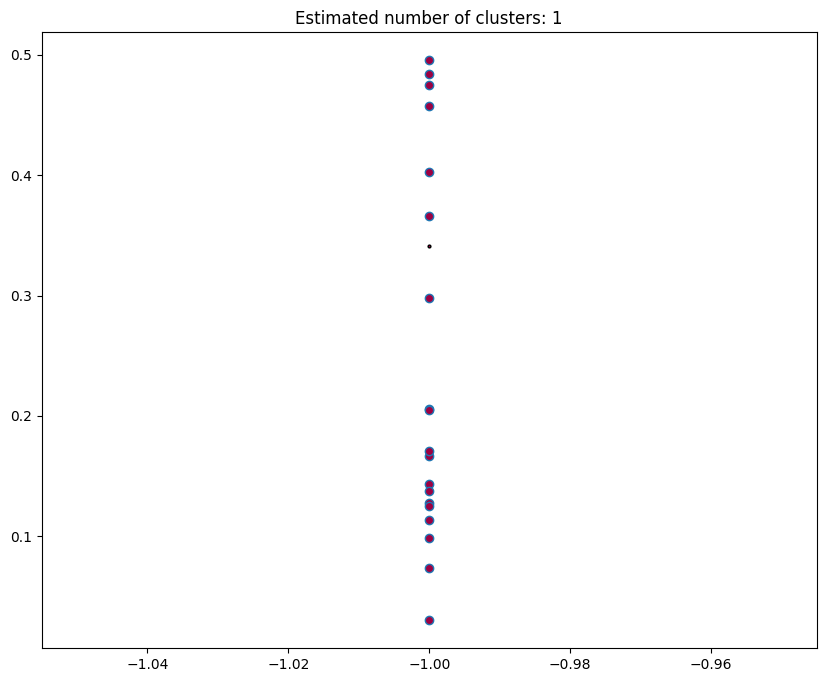

In [241]:
# %matplotlib qt
plt.scatter(Modos[:,0],Modos[:,1],s=0.1)

dbscan = DBSCAN(eps=0.1,n_jobs=Ncores)
dbscan.fit(Modos[:,1].reshape(-1, 1) )

labels = dbscan.labels_
dfdb = pd.DataFrame()
dfdb["U0"] = Modos[:,0]
dfdb["omega"] = Modos[:,1]
dfdb["rc"] = Modos[:,2]
dfdb["c"] = labels
dfdb = dfdb.sort_values(by=['omega','c']).reset_index(drop=True)
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True
plt.figure(figsize=(10,8))

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = Modos[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor=None,
        markersize=6,
    )

    xy = Modos[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=2,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

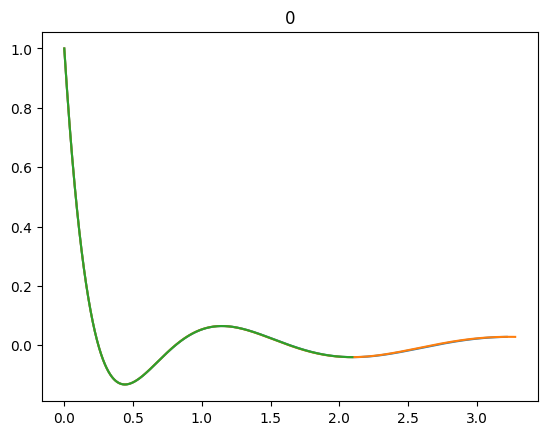

In [242]:
Clusters = sorted(dfdb["c"].drop_duplicates().to_numpy())

r = np.linspace(0,4,100)
for c in Clusters:
    plt.figure()
    Vals = dfdb[dfdb["c"]==c][dfdb.columns[:3]].values
    if c != -1:
        Vals = Vals[np.random.choice(np.arange(0,len(Vals),1),np.min([int(len(Vals)/10+1),20]),replace=False)]
    for U0,omega,rn in Vals:
        try:
            r = np.linspace(0,rn,num=1000)
            Solution = Sol(r,U0,omega)
            plt.plot(r,Solution[:,0],label='{},{}'.format(U0,omega))
        except Warning:
            pass
    # plt.ylim(-0.3,1.1)
    # plt.yscale('log')
    plt.title(c)
    plt.show()

In [243]:
Vals

array([[-1.        ,  0.09866492,  3.21820196],
       [-1.        ,  0.16634466,  3.27914467],
       [-1.        ,  0.12785763,  2.09543809]])

In [244]:
def ShootTail(r,omega0,U0,omegalims,atol=1e-4,Plot=True):
    Solution=Sol(r,U0,omega0) 
    while True:
        Shoot = [(omega0,Solution[-1,0])]

        
        Omega = np.random.uniform(omegalims[0],omegalims[1],50)

        for omega in Omega:
            try:
                Solution=Sol(r,U0,omega) 
                Shoot.append((omega,Solution[-1,0]))
            except Warning:
                pass
        Shoot = np.array(Shoot)

        if len(Shoot)>1 and np.max(Shoot[:,1])>0 and np.min(Shoot[:,1])<0:

            print("Its bounded!")
            omegalims = np.sort(Shoot[(Shoot[:,1] == Shoot[Shoot[:,1]>0,1].min())|(Shoot[:,1] == Shoot[Shoot[:,1]<0,1].max()),0])
            ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### 
            Omegas = np.linspace(omegalims[0],omegalims[1])
            Lim = []
            for omega in Omegas:
                Solution = Sol(r,U0,omega)
                Lim.append(Solution[-1,0])
            Lim = np.array(Lim)
            Omegas_funct = interp1d(Omegas.astype(np.longdouble),Lim.astype(np.longdouble))
            try:
                new_omega = np.longdouble(brentq(Omegas_funct, Omegas.min(), Omegas.max()))
            except:
                new_omega = omega
            ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### ### 
            Solution = Sol(r,U0,new_omega)
            DifZero = np.abs(Solution[-1,0])
            
            if DifZero<atol:
                if Plot:
                    fig, ax = plt.subplots()
                    ax.plot(r[:],Solution[:,0],label='Linear Scale',c='b',ls='--')
                    ax1 = plt.twinx()
                    ax1.semilogy(r[:],np.abs(Solution[:,0]),label='Log Scale',c='k',ls='--')
                    ax1.axhline(atol,ls='--',c='r')
                    plt.legend()
                    plt.show()                
                    plt.close("all")
                print("Success! {:.3e}, {:.3e}".format(DifZero,atol))
                return new_omega,omegalims,Solution
            else:
                new_omega,omegalims,Solution = ShootTail(r,new_omega,U0,omegalims,atol,Plot)
                return new_omega,omegalims,Solution
        else:
            omegalims[0] -= 1e-2
            omegalims[1] += 1e-2



Its bounded!


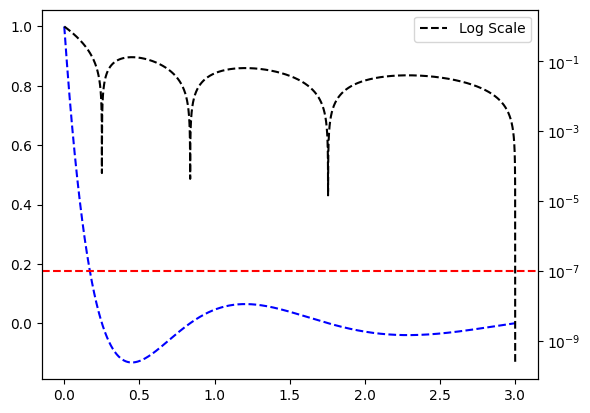

Success! 2.433e-10, 1.000e-07
Its bounded!


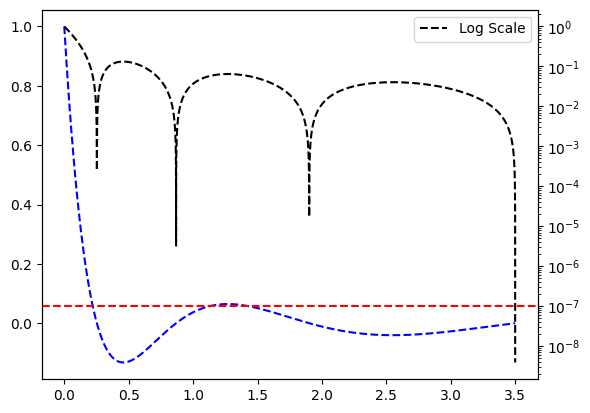

Success! 3.923e-09, 1.000e-07
Its bounded!


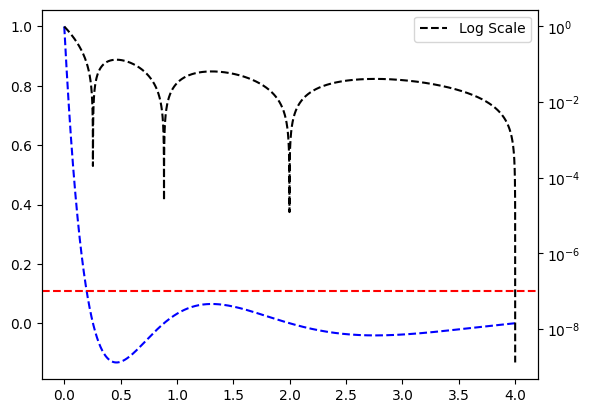

Success! 1.309e-09, 1.000e-07
Its bounded!


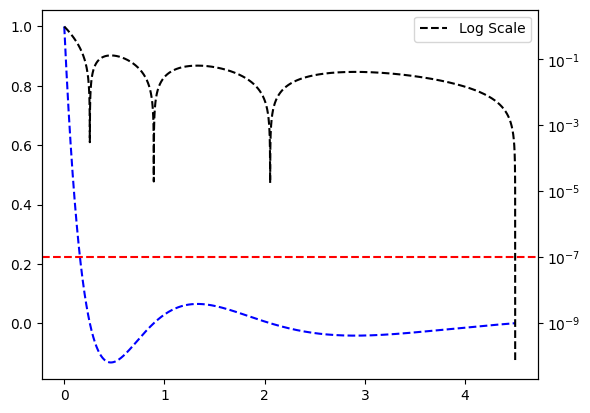

Success! 6.386e-11, 1.000e-07
Its bounded!


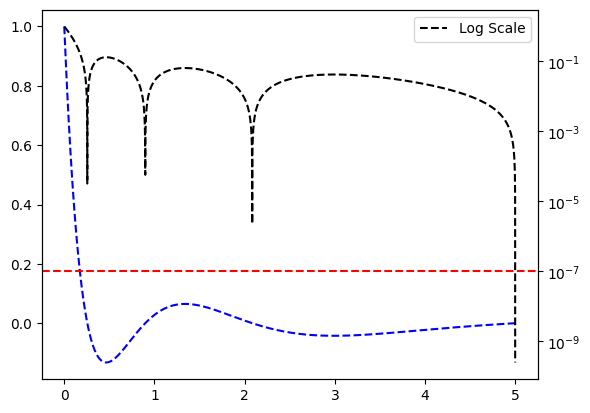

Success! 2.513e-10, 1.000e-07
Its bounded!


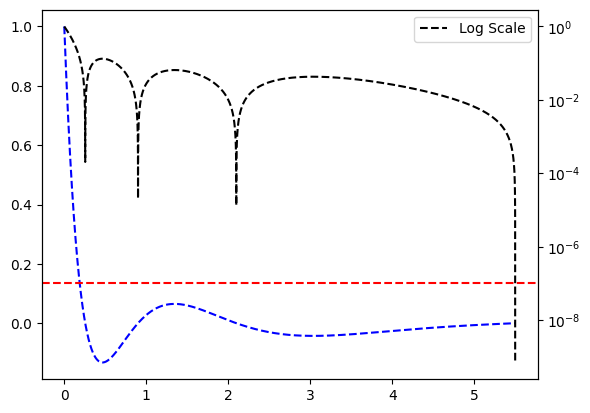

Success! 6.969e-10, 1.000e-07
Its bounded!


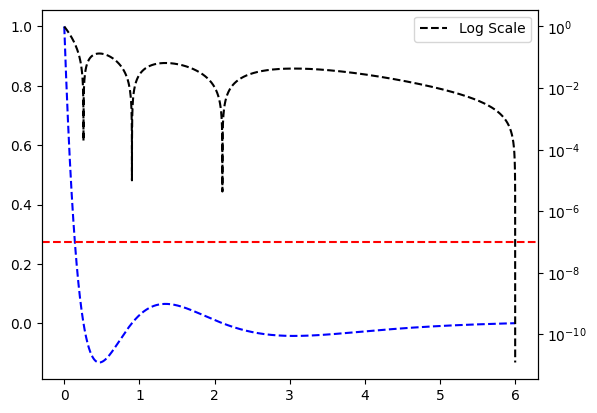

Success! 1.203e-11, 1.000e-07
Its bounded!


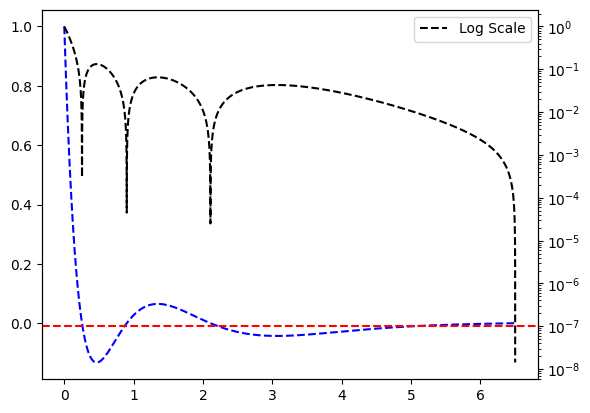

Success! 1.427e-08, 1.000e-07
Its bounded!


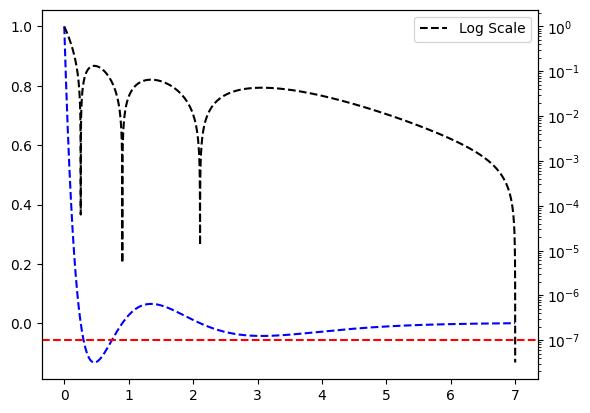

Success! 3.174e-08, 1.000e-07
Its bounded!


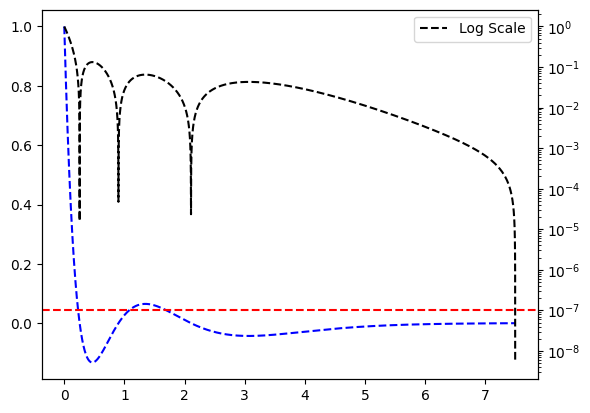

Success! 5.193e-09, 1.000e-07


In [245]:


U0,omega0 =  dfdb[dfdb["c"]==Clusters[0]][["U0","omega"]].values[-1]
# U0,omega0 = -4.75642493187203, -2.453886909561723
# U0,omega0 = -1.6670346096853876,omega
atol = 1e-7

for R in np.arange(3,8,0.5):
    r = np.linspace(0,R,5*2048)
    omega0,omegalims,Solution = ShootTail(r,omega0,U0,[omega0-5*atol,omega0+5*atol],atol)


In [246]:
# r = np.linspace(0,49,3000)
# omega0,omegalims,Solution = ShootTail(r,omega0,U0,[omega0-atol,omega0+atol],atol)

In [247]:
u0origi,omegaorigi = U0,omega0
# r = np.linspace(0,5,512**2)

In [248]:
# hr = r[1]-r[0]
# psi = Solution[:,0]
# Mass = 4*np.pi*np.sum(psi*psi.conjugate()*r**2)*hr
# sol_viejito = np.loadtxt("../../SPUnits/Modos/Modo0.dat")
# r2 = sol_viejito[:,0]
# hr2 = r2[1]-r2[0]
# psi2 = sol_viejito[:,1]
# Mass2 = 4*np.pi*np.sum(psi2*psi2.conjugate()*r2**2)*hr2

Its bounded!
Success! 2.233e-14, 1.000e-06
Its bounded!
Success! 1.281e-07, 1.000e-06
Its bounded!
Success! 4.643e-14, 1.000e-06
Its bounded!
Success! 6.365e-14, 1.000e-06
Its bounded!
Success! 5.208e-15, 1.000e-06


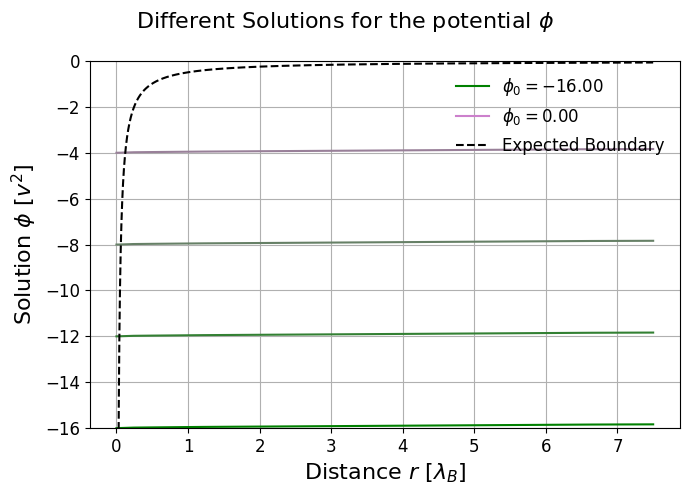

In [249]:
U0,omega0 = u0origi,omegaorigi
U0_recta = np.linspace(-16,-0,5)
Omega_recta = recta(U0_recta,omega0-U0,1)#-AS
atol = 1e-6
Ushoot = []
Size = len(U0_recta)
Countet = 0

plt.figure(figsize=(7,5))
for UU,omegaa in np.vstack([U0_recta,Omega_recta]).T:
    omega0,omegalims,Solution = ShootTail(r,omegaa,UU,[omegaa-atol,omegaa+atol],atol,False)
    if UU==U0_recta[0]:
        plt.plot(r,Solution[:,1],c=(Countet/Size,0.5,Countet/Size),label=r"$\phi_0 = {:.2f}$".format(UU))
    elif UU==U0_recta[-1]:
        plt.plot(r,Solution[:,1],c=(Countet/Size,0.5,Countet/Size),label=r"$\phi_0 = {:.2f}$".format(UU))
    else:
        plt.plot(r,Solution[:,1],c=(Countet/Size,0.5,Countet/Size))
    Masa = TotalMass(Solution[:,0],r)
    V_lim = -Masa/(r[-1])
    Ushoot.append((Solution[-1,1]-V_lim,omega0))
    Countet+=1
plt.plot(r[1:],-Masa/r[1:],ls='--',c='k',label='Expected Boundary')
plt.ylim(U0_recta.min(),0)

plt.xlabel(r"Distance $r$ [$\lambda_B$]",fontsize=16)
plt.ylabel(r"Solution $\phi$ [$v^2$]",fontsize=16)

legend = plt.legend(fontsize=12,loc="best", edgecolor=None)
legend.get_frame().set_alpha(0)
legend.get_frame().set_facecolor((0, 0, 1, 0.1))
plt.suptitle(r"Different Solutions for the potential $\phi$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.tight_layout()
plt.grid(True, which="both", ls="-")
plt.savefig("PotSolEigen.png",dpi=300)
plt.show()
Ushoot = np.array(Ushoot)
U_lim_funct = interp1d(U0_recta,Ushoot[:,0])
Omega_funct = interp1d(U0_recta,Ushoot[:,1])


Its bounded!
Success! 8.591e-08, 1.000e-06


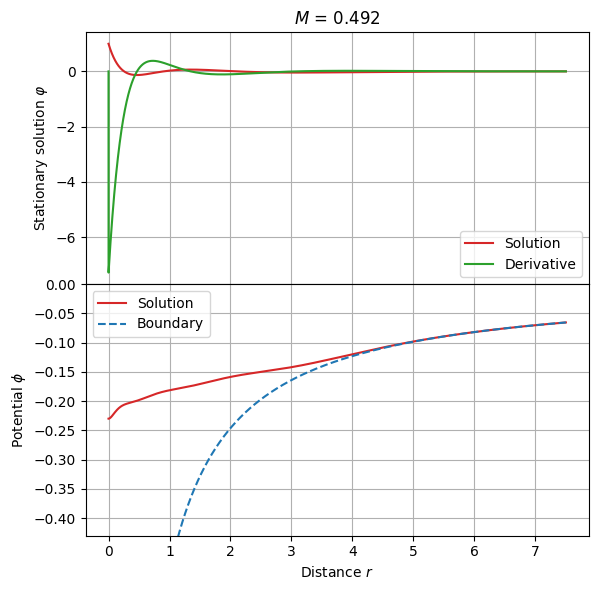

In [250]:
# modo0New = np.loadtxt("Modo0_0.0.dat",skiprows=1)
U = (brentq(U_lim_funct, U0_recta.min(), U0_recta.max()))
omega = Omega_funct(U)
omega,omegalims,Solution = ShootTail(r,omega,U,[omega-atol,omega+atol],atol,False)
Solution = Sol(r,U0=U,omega=omega)
# fig, ax = plt.subplots(2, figsize=(6, 6))

fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(2, 1, hspace=0, wspace=0)
ax = gs.subplots(sharex='col', sharey='row')
ax[0].plot(r, Solution[:, 0], label='Solution',c='tab:red')
ax[1].plot(r, Solution[:, 1], label='Solution',c='tab:red')
ax[0].plot(r, Solution[:, 2], label='Derivative',c='tab:green')

ax[1].plot(r[1:], -TotalMass(Solution[:, 0], r) / r[1:], label='Boundary',c='tab:blue',ls='--')
ax[1].set_ylim(Solution[:, 1].min() - 0.2, 0)

ax[1].set_ylabel(r"Potential $\phi$")
ax[0].set_ylabel(r"Stationary solution $\varphi$")
ax[1].set_xlabel(r"Distance $r$")
ax[1].legend()
ax[0].legend()
ax[0].set_title(r"$ M$ = {:.3f}".format(TotalMass(Solution[:, 0], r)))
ax[0].grid()
ax[1].grid()
# Remove xticks from ax[0]
# ax[0].set_xticks([])
# Remove the gap between subplots
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
plt.savefig("GroundState.png")
plt.show()


In [251]:
Solution

array([[ 1.00000000e+00, -2.29988755e-01,  0.00000000e+00,
         0.00000000e+00],
       [ 9.94652562e-01, -2.29987637e-01, -7.28691235e+00,
         3.04369632e-03],
       [ 9.89324757e-01, -2.29984308e-01, -7.26013798e+00,
         6.03860993e-03],
       ...,
       [-1.60105791e-06, -6.56577291e-02,  1.15175178e-03,
         8.75607044e-03],
       [-7.57489439e-07, -6.56513160e-02,  1.15152547e-03,
         8.75436002e-03],
       [ 8.59136424e-08, -6.56449041e-02,  1.15130017e-03,
         8.75265010e-03]], shape=(10240, 4))

In [252]:
np.where(Solution[:,0]<0)

(array([  350,   351,   352, ..., 10236, 10237, 10238], shape=(8242,)),)

In [13]:
import os

iMax = np.where(Solution[:,0]<0)[0][0] if (Solution[:,0]<0).any() else -1
fn = f"resources/solitons/MBH_{M_BH:.0e}_phi1/Modo_{suffix}_phi1.0.dat"

# TADY JE TEN MAGICKÝ ŘÁDEK: Vytáhne cestu ke složce z názvu souboru a vytvoří ji
os.makedirs(os.path.dirname(fn), exist_ok=True)

file = open(fn,"w")
file.write("#{} {}\n".format(U, omega))
file.write("#r phi U\n")
for r_i, phi_i, U_i in np.vstack([r[:iMax],Solution[:iMax,0],Solution[:iMax,1]]).T:
    file.write("{} {} {}\n".format(r_i, phi_i if phi_i>0 else 0.0, U_i))
file.close()

print(f"-> Úspěšně uloženo do: {fn}")

NameError: name 'M_BH' is not defined

resources/solitons/MBH_1e+08_phi1/Modo_1e8_7.8e0_phi1.0.dat
